# Conflict Event Data Analysis: Ethiopia/Tigray (2020-2022)

## Research Question
How does violence against civilians cluster spatially and temporally during the Tigray conflict (November 2020 to November 2022)?

**Data source:** UCDP Georeferenced Event Dataset (GED) v25.1  
**Study period:** November 2020 to November 2022  
**Geography:** Ethiopia (Tigray, Amhara, Afar, and surrounding regions)

## 1. Setup and Data Loading
Load libraries and read the UCDP GED dataset. Filter to Ethiopia during the study period.

In [1]:
import os
print("Current directory:", os.getcwd())

Current directory: /Users/cansezgin/Library/Mobile Documents/com~apple~CloudDocs/Claude_Projects/Computational Social Sciences/conflict-event-analysis/notebooks


In [2]:
import os
os.chdir('/Users/cansezgin/Library/Mobile Documents/com~apple~CloudDocs/Claude_Projects/Computational Social Sciences/conflict-event-analysis')
print("Now in:", os.getcwd())
print("Files in data/:", os.listdir('data/'))

Now in: /Users/cansezgin/Library/Mobile Documents/com~apple~CloudDocs/Claude_Projects/Computational Social Sciences/conflict-event-analysis
Files in data/: ['README.md', 'GEDEvent_v25_1.csv']


## 2. Data Overview
Breakdown of events by violence type, region, and conflict actors. UCDP categorizes organized violence into three types: state-based conflict (type 1), non-state conflict (type 2), and one-sided violence against civilians (type 3).

In [3]:
import pandas as pd

# Load the full UCDP GED dataset
# Load the full UCDP GED dataset
df = pd.read_csv('data/GEDEvent_v25_1.csv', low_memory=False)
df['date_start'] = pd.to_datetime(df['date_start'])
df['date_end'] = pd.to_datetime(df['date_end'])

# Filter to Ethiopia, November 2020 to November 2022
eth = df[
    (df['country'] == 'Ethiopia')
    & (df['date_start'] >= '2020-11-01')
    & (df['date_start'] <= '2022-11-30')
].copy()

eth['yearmonth'] = eth['date_start'].dt.to_period('M')

print(f"Total UCDP events globally: {len(df):,}")
print(f"Ethiopia events (Nov 2020 - Nov 2022): {len(eth):,}")
print(f"Date range: {eth['date_start'].min().date()} to {eth['date_start'].max().date()}")
print(f"\nEvents by violence type:")
type_labels = {1: 'State-based conflict', 2: 'Non-state conflict', 3: 'One-sided violence'}
for t, label in type_labels.items():
    count = len(eth[eth['type_of_violence'] == t])
    fatalities = eth[eth['type_of_violence'] == t]['best'].sum()
    print(f"  {label}: {count} events, {int(fatalities)} fatalities (best estimate)")

Total UCDP events globally: 385,918
Ethiopia events (Nov 2020 - Nov 2022): 1,764
Date range: 2020-11-01 to 2022-11-29

Events by violence type:
  State-based conflict: 1203 events, 308647 fatalities (best estimate)
  Non-state conflict: 7 events, 395 fatalities (best estimate)
  One-sided violence: 554 events, 9324 fatalities (best estimate)


In [4]:
# Which regions saw the most violence?
print("Events by region (adm_1):")
print(eth['adm_1'].value_counts().to_string())

print(f"\n{'='*60}")

# Focus on one-sided violence (against civilians)
onesided = eth[eth['type_of_violence'] == 3].copy()
print(f"\nOne-sided violence: {len(onesided)} events")
print(f"Civilian deaths: {int(onesided['deaths_civilians'].sum())}")
print(f"\nPerpetrators (side_a) in one-sided violence:")
print(onesided['side_a'].value_counts().to_string())

print(f"\n{'='*60}")
print(f"\nTop conflict dyads across all types:")
print(eth['dyad_name'].value_counts().head(10).to_string())

Events by region (adm_1):
adm_1
Tigray state                  728
Oromiya state                 615
Amhara state                  277
Afar state                     94
Benishangul-Gumuz state        19
Somali state                    7
Gambella state                  5
SNNP state                      4
Addis Ababa Chartered city      1


One-sided violence: 554 events
Civilian deaths: 9324

Perpetrators (side_a) in one-sided violence:
side_a
Government of Ethiopia                           208
Government of Eritrea                            158
Government of Eritrea, Government of Ethiopia     62
TPLF                                              54
OLA                                               45
Fano                                              25
OLA - Fekade Abdisa faction                        2


Top conflict dyads across all types:
dyad_name
Government of Ethiopia - TPLF                                699
Government of Ethiopia - OLA                                 495
Gove

## 3. Temporal Patterns
Monthly event counts over the study period, broken down by violence type and region.

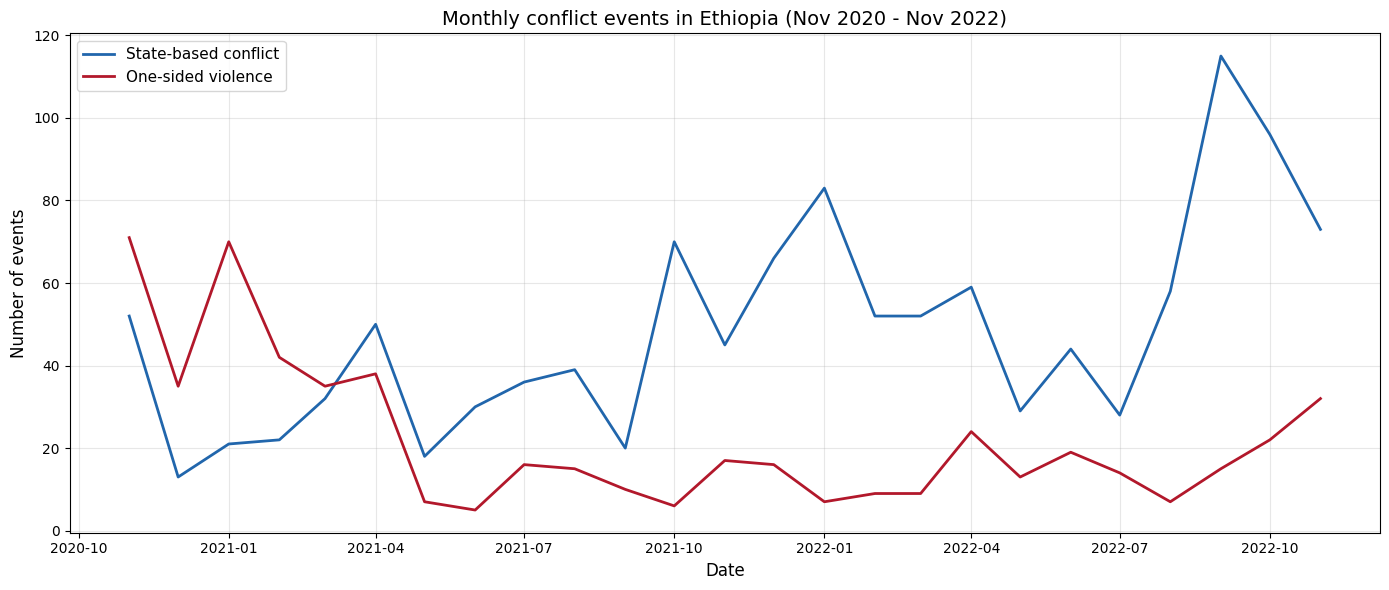

Saved to outputs/monthly_events_by_type.png


In [5]:
# Monthly time series of events by violence type
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(14, 6))

colors = {1: '#2166ac', 2: '#66c2a5', 3: '#b2182b'}
type_labels = {1: 'State-based conflict', 2: 'Non-state conflict', 3: 'One-sided violence'}

for vtype in [1, 3]:
    subset = eth[eth['type_of_violence'] == vtype]
    monthly = subset.groupby('yearmonth').size()
    monthly.index = monthly.index.to_timestamp()
    ax.plot(monthly.index, monthly.values, 
            color=colors[vtype], linewidth=2, label=type_labels[vtype])

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of events', fontsize=12)
ax.set_title('Monthly conflict events in Ethiopia (Nov 2020 - Nov 2022)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/monthly_events_by_type.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/monthly_events_by_type.png")

### 3.1 One-Sided Violence by Region
Violence against civilians across the four most affected regions. Tigray was the initial conflict zone. Violence spread to Amhara and Afar in mid-2021 when TPLF forces advanced beyond Tigray's borders.

In [6]:
# Civilian deaths across all violence types
print("Civilian deaths by violence type:")
for t, label in {1: 'State-based conflict', 2: 'Non-state conflict', 3: 'One-sided violence'}.items():
    subset = eth[eth['type_of_violence'] == t]
    civ_deaths = int(subset['deaths_civilians'].sum())
    total_deaths = int(subset['best'].sum())
    print(f"  {label}: {civ_deaths} civilian deaths out of {total_deaths} total fatalities")

Civilian deaths by violence type:
  State-based conflict: 1676 civilian deaths out of 308647 total fatalities
  Non-state conflict: 0 civilian deaths out of 395 total fatalities
  One-sided violence: 9324 civilian deaths out of 9324 total fatalities


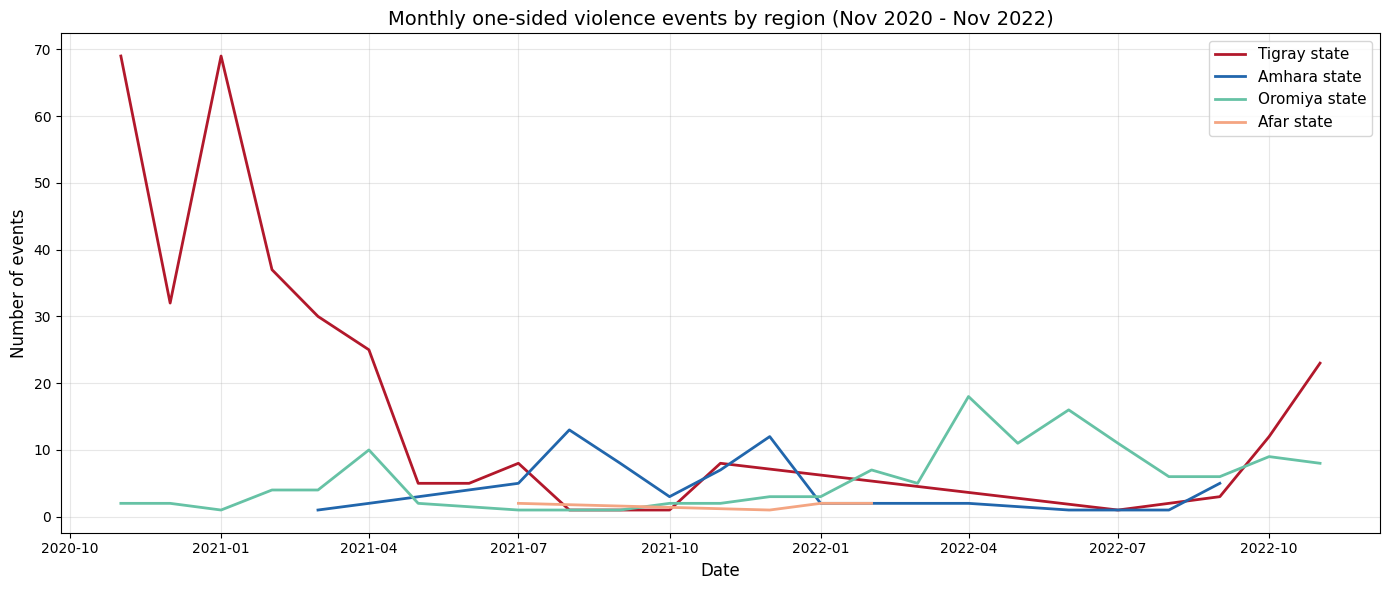

Saved to outputs/onesided_by_region.png


In [7]:
# One-sided violence by region over time
onesided = eth[eth['type_of_violence'] == 3].copy()

fig, ax = plt.subplots(figsize=(14, 6))

region_colors = {
    'Tigray state': '#b2182b',
    'Amhara state': '#2166ac', 
    'Oromiya state': '#66c2a5',
    'Afar state': '#f4a582'
}

for region, color in region_colors.items():
    subset = onesided[onesided['adm_1'] == region]
    if len(subset) > 0:
        monthly = subset.groupby('yearmonth').size()
        monthly.index = monthly.index.to_timestamp()
        ax.plot(monthly.index, monthly.values, color=color, linewidth=2, label=region)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of events', fontsize=12)
ax.set_title('Monthly one-sided violence events by region (Nov 2020 - Nov 2022)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/onesided_by_region.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/onesided_by_region.png")

### 3.2 Perpetrators of Violence Against Civilians
Which armed actors committed one-sided violence, and where did they operate? This disaggregation matters because different perpetrators operated in different regions at different times.

In [23]:
import seaborn as sns

# Perpetrator - region heatmap for one-sided violence
perp_region = pd.crosstab(onesided['side_a'], onesided['adm_1'])

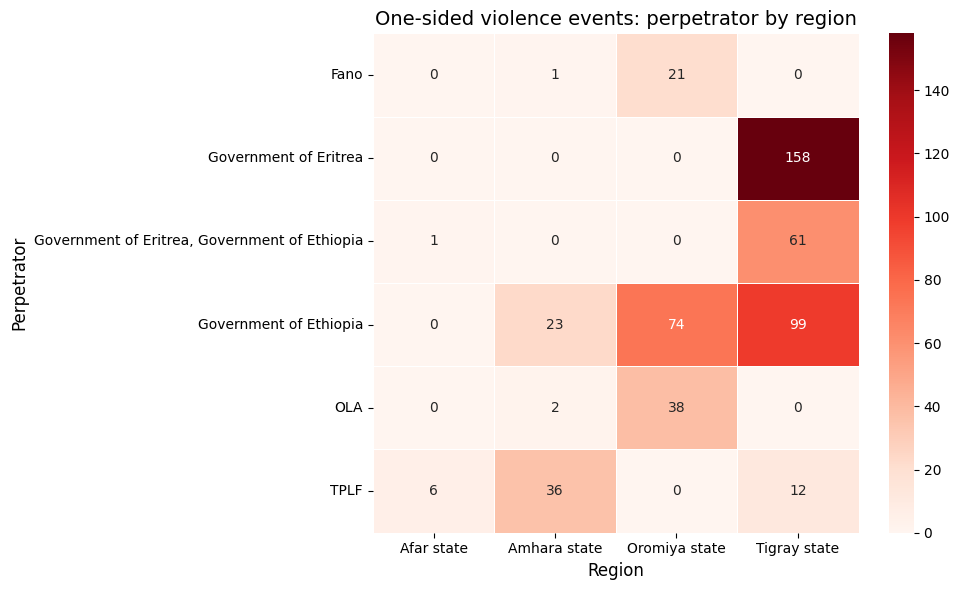

Saved to outputs/perpetrator_region_heatmap.png


### 3.3 Fatality Distribution
How deadly are individual events? Conflict events vary widely in scale. Some involve a single death, others involve mass killings. Understanding this distribution helps contextualize the aggregate numbers.

Top 10 deadliest one-sided violence events:
date_start        adm_1             adm_2                                        side_a  best                                                                                                                                                                                                                                    where_description
2020-11-28 Tigray state      Central zone                         Government of Eritrea   750                                                                                                                     by the Maryam Tsiyon Church, \ndifferent neighbourhods in Axum/Aksum \n\nAxum town woreda\n\nSurrounded by Laelay Maychew woreda
2021-12-19   Afar state       Afar Zone 2 Government of Eritrea, Government of Ethiopia   278                                                                                                                                                                                         

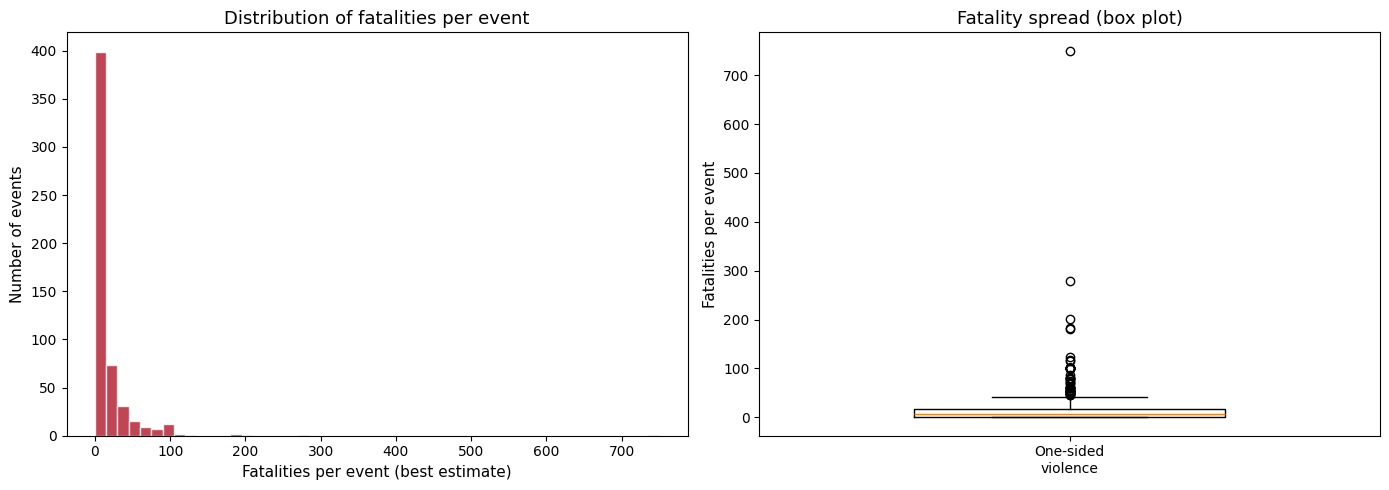


Summary statistics for one-sided violence fatalities:
  Median: 6
  Mean: 16.8
  Max: 750
  Events with 50+ fatalities: 47


In [10]:
# Fatality distribution for one-sided violence events
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of fatalities per event
axes[0].hist(onesided['best'], bins=50, color='#b2182b', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Fatalities per event (best estimate)', fontsize=11)
axes[0].set_ylabel('Number of events', fontsize=11)
axes[0].set_title('Distribution of fatalities per event', fontsize=13)

# Right: top 10 deadliest one-sided violence events
top_events = onesided.nlargest(10, 'best')[['date_start', 'adm_1', 'adm_2', 'side_a', 'best', 'where_description']]
print("Top 10 deadliest one-sided violence events:")
print(top_events.to_string(index=False))

# Summary statistics
axes[1].boxplot([onesided['best']], vert=True, widths=0.5)
axes[1].set_ylabel('Fatalities per event', fontsize=11)
axes[1].set_title('Fatality spread (box plot)', fontsize=13)
axes[1].set_xticklabels(['One-sided\nviolence'])

plt.tight_layout()
plt.savefig('outputs/fatality_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSummary statistics for one-sided violence fatalities:")
print(f"  Median: {onesided['best'].median():.0f}")
print(f"  Mean: {onesided['best'].mean():.1f}")
print(f"  Max: {onesided['best'].max():.0f}")
print(f"  Events with 50+ fatalities: {len(onesided[onesided['best'] >= 50])}")

### 4. Temporal Dynamics by Conflict Phase
The Tigray conflict had distinct phases. Breaking the study period into phases reveals how the nature and geography of violence shifted over time.

- **Phase 1 (Nov 2020 - Jun 2021):** Initial federal offensive into Tigray
- **Phase 2 (Jul 2021 - Dec 2021):** TPLF counteroffensive, expansion into Amhara and Afar
- **Phase 3 (Jan 2022 - Nov 2022):** Stalemate, renewed fighting, ceasefire agreement

All events by conflict phase:

  Phase 1: Federal offensive
    Total events: 545
    One-sided violence events: 303
    Civilian deaths (one-sided): 6273
    Top regions: {'Tigray state': 459, 'Oromiya state': 65, 'Amhara state': 12}

  Phase 2: TPLF counteroffensive
    Total events: 357
    One-sided violence events: 80
    Civilian deaths (one-sided): 1274
    Top regions: {'Amhara state': 163, 'Oromiya state': 119, 'Tigray state': 46}

  Phase 3: Stalemate to ceasefire
    Total events: 862
    One-sided violence events: 171
    Civilian deaths (one-sided): 1777
    Top regions: {'Oromiya state': 431, 'Tigray state': 223, 'Amhara state': 102}


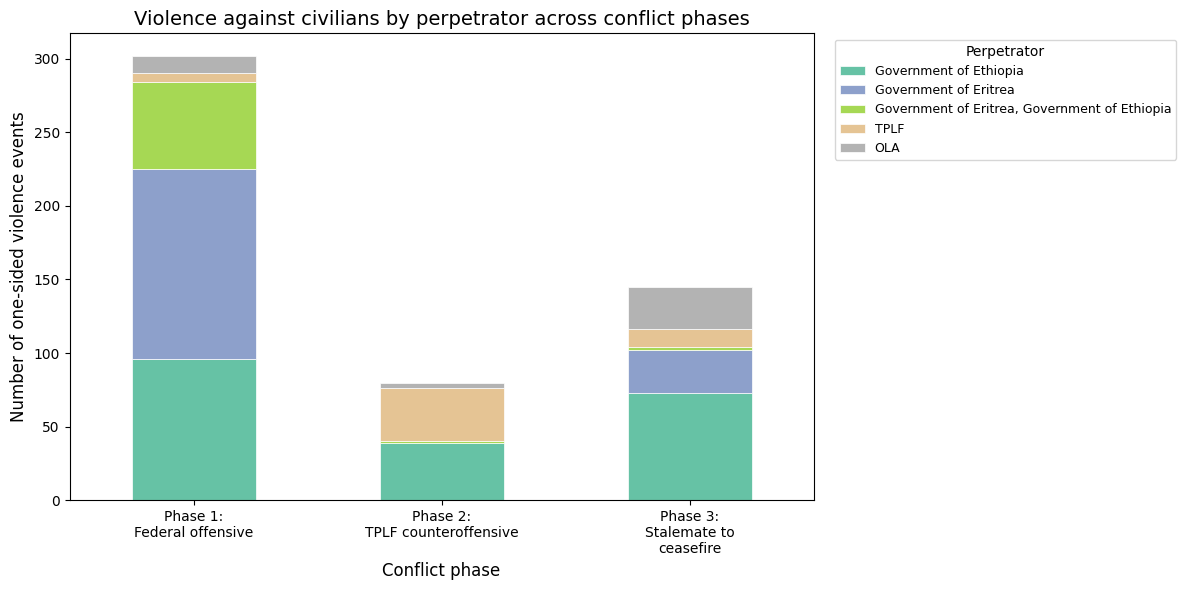

Saved to outputs/onesided_by_phase_perpetrator.png


In [11]:
# Define conflict phases
def assign_phase(date):
    if date <= pd.Timestamp('2021-06-30'):
        return 'Phase 1: Federal offensive'
    elif date <= pd.Timestamp('2021-12-31'):
        return 'Phase 2: TPLF counteroffensive'
    else:
        return 'Phase 3: Stalemate to ceasefire'

eth['phase'] = eth['date_start'].apply(assign_phase)
onesided = eth[eth['type_of_violence'] == 3].copy()

# Events and fatalities by phase
print("All events by conflict phase:")
for phase in ['Phase 1: Federal offensive', 'Phase 2: TPLF counteroffensive', 'Phase 3: Stalemate to ceasefire']:
    subset = eth[eth['phase'] == phase]
    os_subset = onesided[onesided['date_start'].apply(assign_phase) == phase]
    print(f"\n  {phase}")
    print(f"    Total events: {len(subset)}")
    print(f"    One-sided violence events: {len(os_subset)}")
    print(f"    Civilian deaths (one-sided): {int(os_subset['deaths_civilians'].sum())}")
    print(f"    Top regions: {subset['adm_1'].value_counts().head(3).to_dict()}")

# Stacked bar chart: one-sided violence by phase and perpetrator
fig, ax = plt.subplots(figsize=(12, 6))

phases = ['Phase 1: Federal offensive', 'Phase 2: TPLF counteroffensive', 'Phase 3: Stalemate to ceasefire']
top_perps = onesided['side_a'].value_counts().head(5).index.tolist()

phase_perp = pd.crosstab(
    onesided['date_start'].apply(assign_phase),
    onesided['side_a']
)
phase_perp = phase_perp.reindex(phases)
phase_perp = phase_perp[top_perps]

phase_perp.plot(kind='bar', stacked=True, ax=ax, 
                colormap='Set2', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Conflict phase', fontsize=12)
ax.set_ylabel('Number of one-sided violence events', fontsize=12)
ax.set_title('Violence against civilians by perpetrator across conflict phases', fontsize=14)
ax.legend(title='Perpetrator', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.set_xticklabels(['Phase 1:\nFederal offensive', 'Phase 2:\nTPLF counteroffensive', 'Phase 3:\nStalemate to\nceasefire'], rotation=0)
plt.tight_layout()
plt.savefig('outputs/onesided_by_phase_perpetrator.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/onesided_by_phase_perpetrator.png")

## 5. Spatial Distribution of Violence Against Civilians
Where did one-sided violence concentrate? This section maps individual events and examines geographic clustering across the study period and conflict phases.

In [12]:
import folium
from folium.plugins import HeatMap

# Create a base map centered on northern Ethiopia
center_lat = onesided['latitude'].mean()
center_lon = onesided['longitude'].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=6, tiles='CartoDB positron')

# Color events by perpetrator
perp_colors = {
    'Government of Ethiopia': 'red',
    'Government of Eritrea': 'orange',
    'Government of Eritrea, Government of Ethiopia': 'darkred',
    'TPLF': 'blue',
    'OLA': 'green',
    'Fano': 'purple'
}

for _, row in onesided.iterrows():
    color = perp_colors.get(row['side_a'], 'gray')
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=max(2, min(row['best'] * 0.3, 15)),
        color=color,
        fill=True,
        fill_opacity=0.6,
        popup=f"{row['side_a']}<br>{row['date_start'].date()}<br>{row['where_description']}<br>Deaths: {int(row['best'])}"
    ).add_to(m)

# Save the map
m.save('outputs/onesided_violence_map.html')
print("Interactive map saved to outputs/onesided_violence_map.html")
print("Open this file in your browser to explore it.")
print(f"\nTotal events mapped: {len(onesided)}")
print(f"Events by perpetrator color:")
for perp, color in perp_colors.items():
    count = len(onesided[onesided['side_a'] == perp])
    if count > 0:
        print(f"  {color}: {perp} ({count} events)")

Interactive map saved to outputs/onesided_violence_map.html
Open this file in your browser to explore it.

Total events mapped: 554
Events by perpetrator color:
  red: Government of Ethiopia (208 events)
  orange: Government of Eritrea (158 events)
  darkred: Government of Eritrea, Government of Ethiopia (62 events)
  blue: TPLF (54 events)
  green: OLA (45 events)
  purple: Fano (25 events)


### 5.1 Static Map of One-Sided Violence
A matplotlib-based map that renders in all environments including GitHub's notebook viewer.

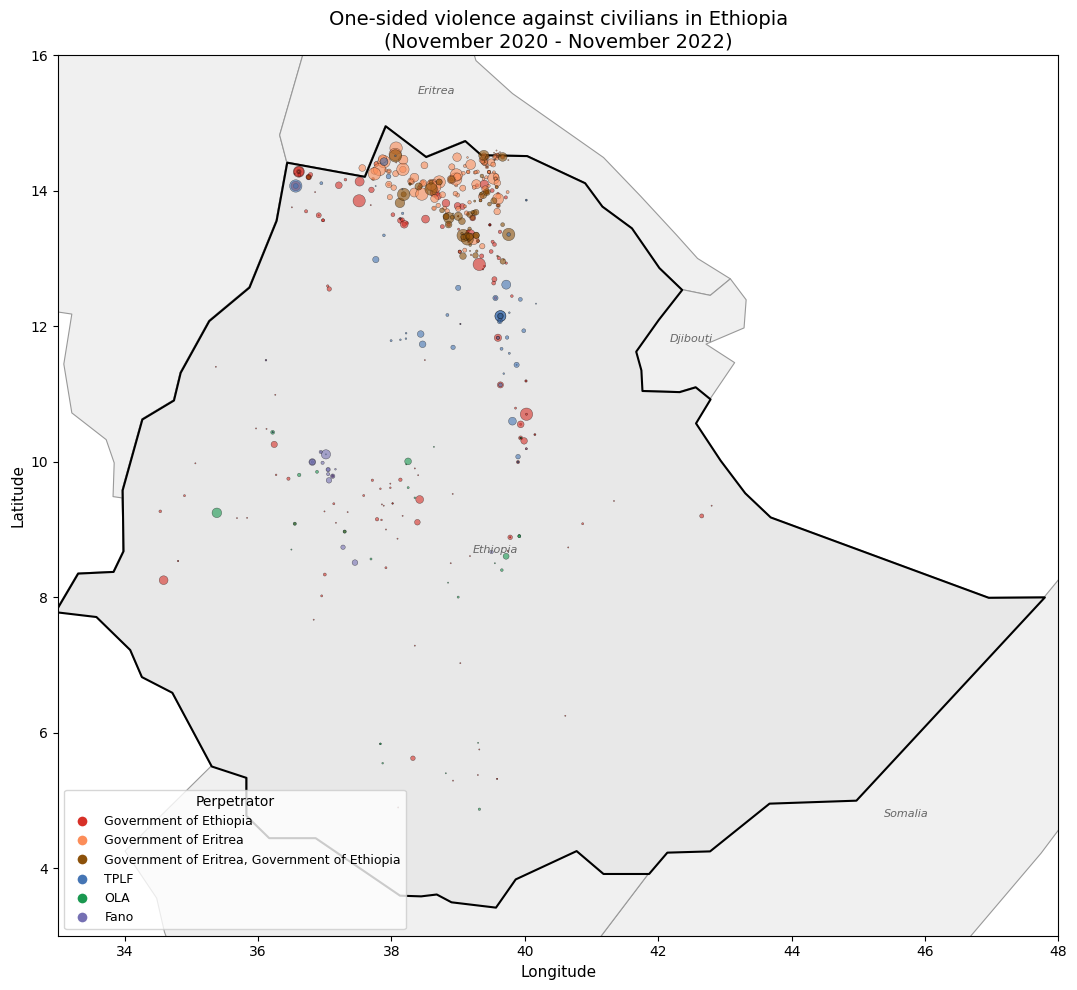

Saved to outputs/onesided_static_map.png


In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Create a GeoDataFrame from the one-sided violence data
gdf = gpd.GeoDataFrame(
    onesided,
    geometry=gpd.points_from_xy(onesided.longitude, onesided.latitude),
    crs='EPSG:4326'
)

# Load world boundaries from Natural Earth
world = gpd.read_file('https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip')

# Countries in the region for context
region = world[world['NAME'].isin(['Ethiopia', 'Eritrea', 'Somalia', 'Kenya', 'Sudan', 'South Sudan', 'Djibouti'])]
ethiopia = world[world['NAME'] == 'Ethiopia']

fig, ax = plt.subplots(figsize=(12, 10))

# Plot neighboring countries in light gray
region.plot(ax=ax, color='#f0f0f0', edgecolor='#999999', linewidth=0.8)

# Plot Ethiopia with a distinct border
ethiopia.plot(ax=ax, color='#e8e8e8', edgecolor='black', linewidth=1.5)

# Plot perpetrator groups with different colors
perp_colors = {
    'Government of Ethiopia': '#d73027',
    'Government of Eritrea': '#fc8d59',
    'Government of Eritrea, Government of Ethiopia': '#8c510a',
    'TPLF': '#4575b4',
    'OLA': '#1a9850',
    'Fano': '#7570b3'
}

for perp, color in perp_colors.items():
    subset = gdf[gdf['side_a'] == perp]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, markersize=subset['best'].clip(upper=100) * 0.8,
                    alpha=0.6, edgecolor='black', linewidth=0.3)

# Set map bounds to Ethiopia and surroundings
ax.set_xlim(33, 48)
ax.set_ylim(3, 16)
ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.set_title('One-sided violence against civilians in Ethiopia\n(November 2020 - November 2022)', fontsize=14)

# Add country labels
for _, row in region.iterrows():
    centroid = row.geometry.centroid
    if 33 < centroid.x < 48 and 3 < centroid.y < 16:
        ax.annotate(row['NAME'], xy=(centroid.x, centroid.y), fontsize=8,
                    ha='center', color='#666666', fontstyle='italic')

# Legend
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                          markersize=8, label=p) for p, c in perp_colors.items()]
ax.legend(handles=legend_elements, loc='lower left', fontsize=9, title='Perpetrator')

plt.tight_layout()
plt.savefig('outputs/onesided_static_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/onesided_static_map.png")

### 5.2 Violence Against Civilians by Conflict Phase
Three maps side by side showing how the geography of one-sided violence changed as the conflict evolved. Phase 1 concentrated in Tigray. Phase 2 spread into Amhara and Afar as TPLF forces advanced. Phase 3 saw a return to Tigray-focused violence before the ceasefire.

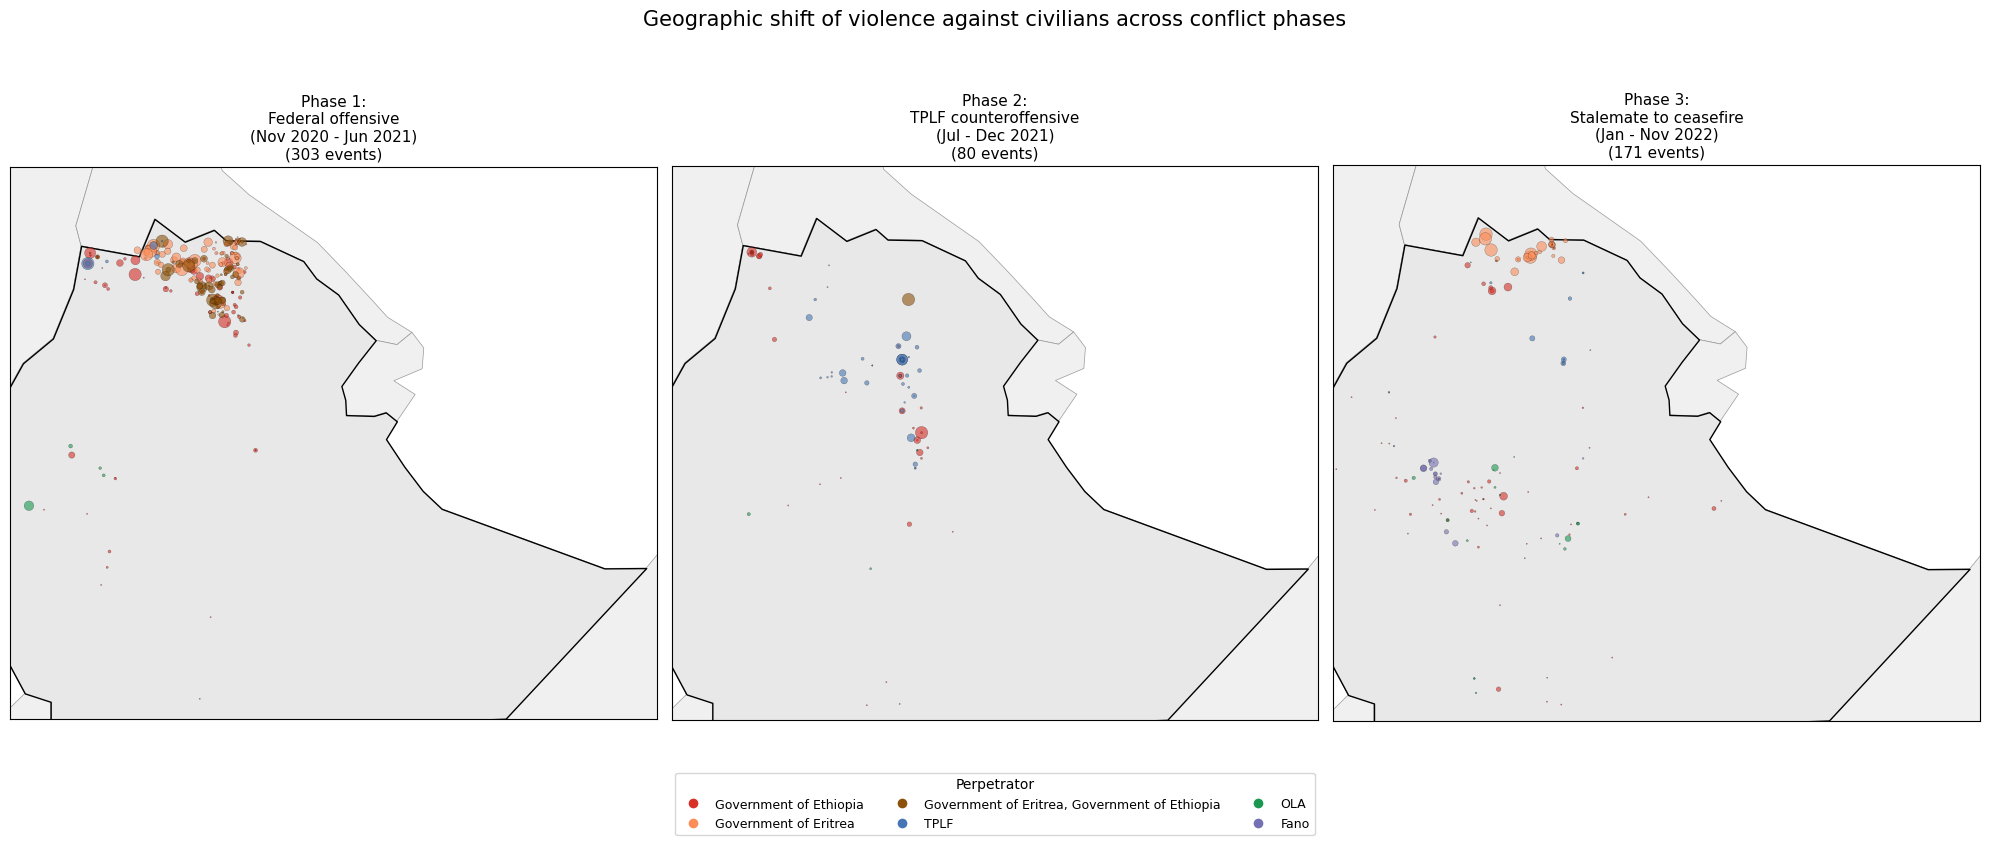

Saved to outputs/onesided_by_phase_maps.png


In [14]:
# Side-by-side maps by conflict phase
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

phases = ['Phase 1: Federal offensive', 'Phase 2: TPLF counteroffensive', 'Phase 3: Stalemate to ceasefire']
phase_short = ['Phase 1:\nFederal offensive\n(Nov 2020 - Jun 2021)', 
               'Phase 2:\nTPLF counteroffensive\n(Jul - Dec 2021)', 
               'Phase 3:\nStalemate to ceasefire\n(Jan - Nov 2022)']

for i, (phase, title) in enumerate(zip(phases, phase_short)):
    ax = axes[i]
    
    # Background map
    region.plot(ax=ax, color='#f0f0f0', edgecolor='#999999', linewidth=0.5)
    ethiopia.plot(ax=ax, color='#e8e8e8', edgecolor='black', linewidth=1)
    
    # Filter one-sided violence for this phase
    phase_data = gdf[gdf['date_start'].apply(assign_phase) == phase]
    
    if len(phase_data) > 0:
        for perp, color in perp_colors.items():
            subset = phase_data[phase_data['side_a'] == perp]
            if len(subset) > 0:
                subset.plot(ax=ax, color=color, 
                           markersize=subset['best'].clip(upper=100) * 0.8,
                           alpha=0.6, edgecolor='black', linewidth=0.2)
    
    ax.set_xlim(35, 48)
    ax.set_ylim(5, 16)
    ax.set_title(f'{title}\n({len(phase_data)} events)', fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

# Shared legend
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                          markersize=8, label=p) for p, c in perp_colors.items() 
                   if len(gdf[gdf['side_a'] == p]) > 0]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=9,
           title='Perpetrator', bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Geographic shift of violence against civilians across conflict phases', 
             fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('outputs/onesided_by_phase_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/onesided_by_phase_maps.png")

## 6. Spatial Clustering with DBSCAN
Visual inspection suggests violence against civilians concentrated in specific areas. DBSCAN (Density-Based Spatial Clustering of Applications with Noise) identifies these clusters algorithmically. Unlike k-means, DBSCAN does not require specifying the number of clusters in advance. It finds clusters based on density: areas where many events occur close together.

Two parameters control DBSCAN:
- **eps**: the maximum distance (in kilometers) between two events for them to be considered neighbors
- **min_samples**: the minimum number of events needed to form a cluster

Events not assigned to any cluster are labeled as "noise," meaning isolated incidents.

In [15]:
pip install --force-reinstall scipy

  Using cached scipy-1.17.1-cp311-cp311-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached numpy-2.4.3-cp311-cp311-macosx_14_0_arm64.whl.metadata (6.6 kB)
Using cached scipy-1.17.1-cp311-cp311-macosx_14_0_arm64.whl (20.3 MB)
Using cached numpy-2.4.3-cp311-cp311-macosx_14_0_arm64.whl (5.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: scipy
    Found existing installation: scipy 1.17.1
    Uninstalling scipy-1.17.1:
      Successfully uninstalled scipy-1.17.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.4.3 which is incompatible.
tensorflow 2.15.1 requires numpy<2.0.0,>=1.23.5, but you have numpy 2.4.3 which is incompatible.
Note: you may need to restart the kerne

In [16]:
pip install "numpy<2" --force-reinstall

  Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl.metadata (114 kB)
Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl (14.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.3
    Uninstalling numpy-2.4.3:
      Successfully uninstalled numpy-2.4.3
Note: you may need to restart the kernel to use updated packages.


In [19]:
import numpy as np
from sklearn.cluster import DBSCAN

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.chdir('/Users/cansezgin/Library/Mobile Documents/com~apple~CloudDocs/Claude_Projects/Computational Social Sciences/conflict-event-analysis')

df = pd.read_csv('data/GEDEvent_v25_1.csv', low_memory=False)
df['date_start'] = pd.to_datetime(df['date_start'])
df['date_end'] = pd.to_datetime(df['date_end'])

eth = df[
    (df['country'] == 'Ethiopia')
    & (df['date_start'] >= '2020-11-01')
    & (df['date_start'] <= '2022-11-30')
].copy()

eth['yearmonth'] = eth['date_start'].dt.to_period('M')

In [21]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Use one-sided violence events with coordinates
coords = onesided[['latitude', 'longitude']].values

# DBSCAN needs distance in radians when using haversine metric
# Convert degrees to radians
coords_rad = np.radians(coords)

# eps = 50km converted to radians (earth radius ~ 6371km)
# 50km is chosen because violence clusters in this conflict tend to span 
# multiple neighboring towns within a zone of operations
eps_rad = 50 / 6371

# Run DBSCAN with haversine distance
db = DBSCAN(eps=eps_rad, min_samples=5, metric='haversine')
onesided_clustered = onesided.copy()
onesided_clustered['cluster'] = db.fit_predict(coords_rad)

n_clusters = len(set(onesided_clustered['cluster'])) - (1 if -1 in onesided_clustered['cluster'].values else 0)
n_noise = len(onesided_clustered[onesided_clustered['cluster'] == -1])

print(f"DBSCAN results (eps=50km, min_samples=5):")
print(f"  Clusters found: {n_clusters}")
print(f"  Events in clusters: {len(onesided_clustered[onesided_clustered['cluster'] != -1])}")
print(f"  Noise events (unclustered): {n_noise}")

print(f"\nCluster details:")
for c in sorted(onesided_clustered['cluster'].unique()):
    if c == -1:
        continue
    cluster_data = onesided_clustered[onesided_clustered['cluster'] == c]
    top_region = cluster_data['adm_1'].value_counts().index[0]
    top_perp = cluster_data['side_a'].value_counts().index[0]
    print(f"  Cluster {c}: {len(cluster_data)} events, "
          f"{int(cluster_data['best'].sum())} fatalities, "
          f"main region: {top_region}, main perpetrator: {top_perp}")

DBSCAN results (eps=50km, min_samples=5):
  Clusters found: 9
  Events in clusters: 524
  Noise events (unclustered): 30

Cluster details:
  Cluster 0: 385 events, 8444 fatalities, main region: Tigray state, main perpetrator: Government of Eritrea
  Cluster 1: 6 events, 40 fatalities, main region: Benishangul-Gumuz state, main perpetrator: Government of Ethiopia
  Cluster 2: 66 events, 454 fatalities, main region: Oromiya state, main perpetrator: Government of Ethiopia
  Cluster 3: 17 events, 78 fatalities, main region: Oromiya state, main perpetrator: OLA
  Cluster 4: 6 events, 52 fatalities, main region: Oromiya state, main perpetrator: Government of Ethiopia
  Cluster 5: 12 events, 89 fatalities, main region: Amhara state, main perpetrator: TPLF
  Cluster 6: 13 events, 68 fatalities, main region: Oromiya state, main perpetrator: OLA
  Cluster 7: 14 events, 21 fatalities, main region: Oromiya state, main perpetrator: Government of Ethiopia
  Cluster 8: 5 events, 5 fatalities, main re

### 6.1 DBSCAN Cluster Map
Map of the nine spatial clusters identified by DBSCAN. Cluster 0 (Tigray) contains 69% of all one-sided violence events. The remaining clusters capture violence in Oromiya (OLA insurgency), Amhara (TPLF counteroffensive), and Benishangul-Gumuz.

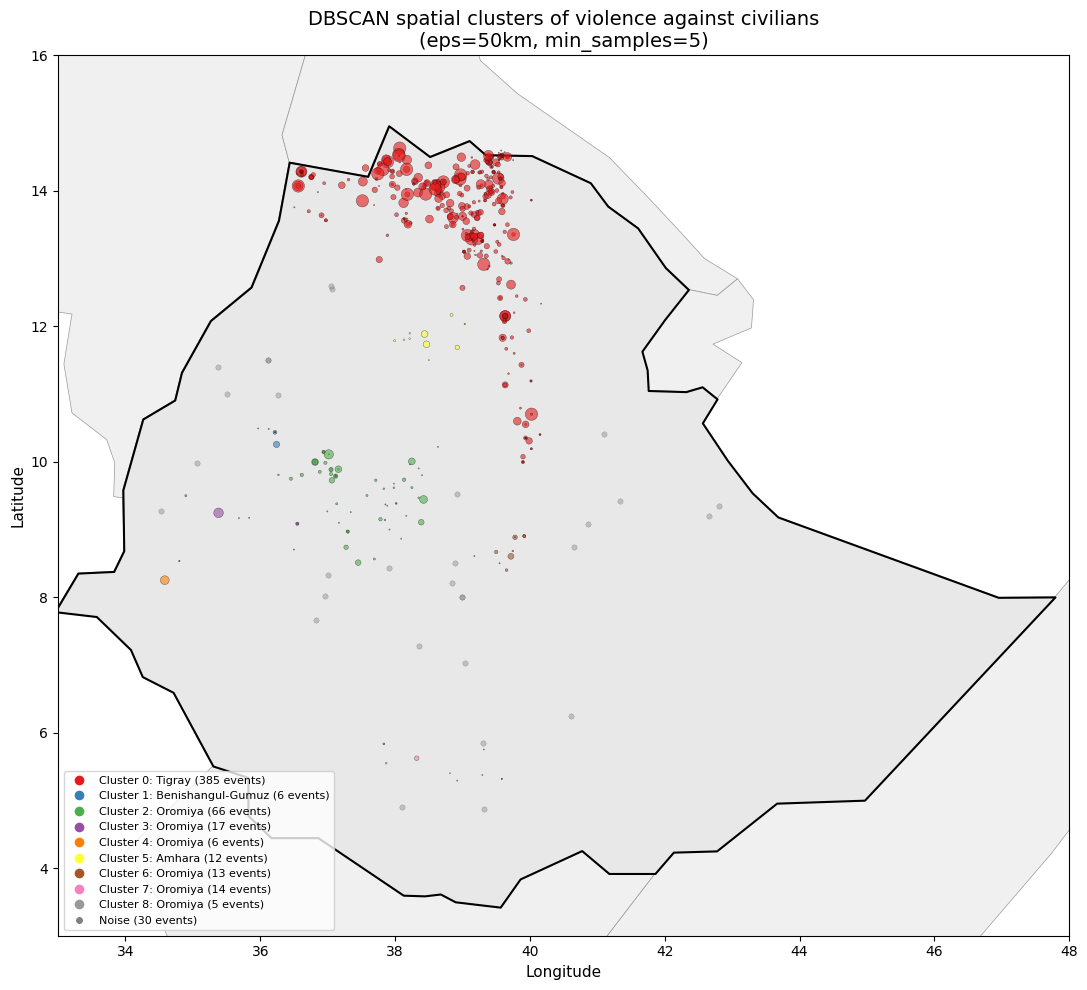

Saved to outputs/dbscan_clusters_map.png


In [22]:
import geopandas as gpd
from matplotlib.lines import Line2D

# Create GeoDataFrame with cluster labels
gdf_clustered = gpd.GeoDataFrame(
    onesided_clustered,
    geometry=gpd.points_from_xy(onesided_clustered.longitude, onesided_clustered.latitude),
    crs='EPSG:4326'
)

# Load boundaries
world = gpd.read_file('https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip')
region = world[world['NAME'].isin(['Ethiopia', 'Eritrea', 'Somalia', 'Kenya', 'Sudan', 'South Sudan', 'Djibouti'])]
ethiopia = world[world['NAME'] == 'Ethiopia']

fig, ax = plt.subplots(figsize=(13, 10))

# Background
region.plot(ax=ax, color='#f0f0f0', edgecolor='#999999', linewidth=0.5)
ethiopia.plot(ax=ax, color='#e8e8e8', edgecolor='black', linewidth=1.5)

# Color map for clusters
cluster_colors = plt.cm.Set1(np.linspace(0, 1, n_clusters))

# Plot noise points in gray
noise = gdf_clustered[gdf_clustered['cluster'] == -1]
if len(noise) > 0:
    noise.plot(ax=ax, color='gray', markersize=15, alpha=0.4, edgecolor='black', linewidth=0.2)

# Plot each cluster
for c in range(n_clusters):
    cluster_data = gdf_clustered[gdf_clustered['cluster'] == c]
    color = cluster_colors[c]
    cluster_data.plot(ax=ax, color=color,
                      markersize=cluster_data['best'].clip(upper=100) * 0.8,
                      alpha=0.6, edgecolor='black', linewidth=0.3)

ax.set_xlim(33, 48)
ax.set_ylim(3, 16)
ax.set_title('DBSCAN spatial clusters of violence against civilians\n(eps=50km, min_samples=5)', fontsize=14)
ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)

# Legend
legend_elements = []
for c in range(n_clusters):
    cdata = onesided_clustered[onesided_clustered['cluster'] == c]
    top_region = cdata['adm_1'].value_counts().index[0].replace(' state', '')
    legend_elements.append(
        Line2D([0], [0], marker='o', color='w', markerfacecolor=cluster_colors[c],
               markersize=8, label=f'Cluster {c}: {top_region} ({len(cdata)} events)')
    )
legend_elements.append(
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markersize=6, label=f'Noise ({n_noise} events)')
)
ax.legend(handles=legend_elements, loc='lower left', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/dbscan_clusters_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/dbscan_clusters_map.png")

## 7. Key Findings

1. **Scale:** 1,764 conflict events occurred in Ethiopia between November 2020 and November 2022, including 554 events of one-sided violence against civilians resulting in an estimated 9,324 civilian deaths.

2. **Perpetrators:** Government forces (Ethiopia and Eritrea) committed the majority of documented violence against civilians (428 of 554 events). TPLF, OLA, and Fano militia account for the remainder.

3. **Geographic concentration:** DBSCAN clustering shows 69% of one-sided violence events (385 of 554) belong to a single spatial cluster in Tigray. Remaining clusters are in Oromiya (OLA insurgency), Amhara (TPLF counteroffensive), and Benishangul-Gumuz.

4. **Temporal dynamics:** Violence against civilians peaked during Phase 1 (federal offensive into Tigray) and shifted geographically during Phase 2 as TPLF forces advanced into Amhara and Afar regions.

5. **Data source:** UCDP GED v25.1 records only events with at least one fatality from organized violence. Actual civilian harm is likely higher than documented here.

## Next Steps
- Notebook 02: Geospatial analysis with administrative boundary choropleths and kernel density heatmaps
- Notebook 03: Publication-quality figures and final visualizations